# CIS 5370 Final Project

## Project 1 - Intrusion Detection for Industrial Control Systems

- Kyle Brindle
- Rayhan Alcena

In [5]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
from nfstream import NFStreamer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.ensemble import IsolationForest
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from datetime import time

## Loading Files

In [6]:
# Base path to the datasets
BASE_PATH = Path.cwd() / "data/SWaT_A6_Dec_2019/"
SENSOR_READINGS_PATH = BASE_PATH / "csv/"
NETWORK_READINGS_PATH = BASE_PATH / "pcap/"

# Sensor Readings CSV/XLSX file paths
dec_2019_file_path = SENSOR_READINGS_PATH / "Dec2019.xlsx"

# Network Readings CSV/XLSX file paths
converted_pcap_file_path = BASE_PATH / "csv_from_pcap/"

# Loading the CSV/XLSX files (We had to skip the first 9 rows (0-9))
sensor_readings_df = pd.read_excel(dec_2019_file_path, skiprows=9)

# Converts all pcaps in a directory into CSV files with network flows, they will then have to be moved into a directory calld csv_from_pcap
# i = 0;
# for file_name in os.listdir(NETWORK_READINGS_PATH):
#     if file_name.endswith(".pcap"):
#         converted_pcap_file_path = NETWORK_READINGS_PATH / ("0" + str(i) + "_converted.csv")
#         print(f"Converting {file_name}")
#         streamer = NFStreamer(source = NETWORK_READINGS_PATH / file_name).to_csv(converted_pcap_file_path)
#         print(f"{file_name} converted with {streamer} flows")
#         i = i + 1

# Converts a singular pcap into a CSV file with network flows
# streamer = NFStreamer(source=NETWORK_READINGS_PATH / "Dec2019_00001_20191206102207.pcap").to_csv(path=test_converted_pcap_file_path)
# print(f"Exported {streamer} flows")

# Adds multiple csvs into one dataframe.
temp_dfs_list = []
for i in range (0,15):
        file_name = ("0" + f"{i}_converted.csv")
        file_path = Path.joinpath(converted_pcap_file_path, file_name)
        temp_df = pd.read_csv(file_path)
        temp_dfs_list.append(temp_df)

network_readings_df = pd.concat(temp_dfs_list, ignore_index = True)
del temp_dfs_list
del temp_df

C:\Users\kyleb\AppData\Local\Temp\ipykernel_19288\1268578496.py:34: DtypeWarning: Columns (0: requested_server_name, 1: user_agent, 2: content_type) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_path)
C:\Users\kyleb\AppData\Local\Temp\ipykernel_19288\1268578496.py:34: DtypeWarning: Columns (0: requested_server_name) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_path)
C:\Users\kyleb\AppData\Local\Temp\ipykernel_19288\1268578496.py:34: DtypeWarning: Columns (0: requested_server_name, 1: client_fingerprint, 2: server_fingerprint, 3: user_agent, 4: content_type) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_path)


In [114]:
# Shows the first 10 observations in the dataframe
sensor_readings_df.head(10)

,t_stamp,P1_STATE,LIT101.Pv,FIT101.Pv,MV101.Status,P101.Status,P102.Status,P2_STATE,FIT201.Pv,AIT201.Pv,...,FIT601.Pv,P601.Status,P602.Status,P603.Status,LSH601.Alarm,LSL601.Alarm,LSH602.Alarm,LSL602.Alarm,LSH603.Alarm,LSL603.Alarm
0,2019-12-06 10:05:00,3,658.661255,0.0,1,2.0,1,2,2.313523,35.215330,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
1,2019-12-06 10:05:01,3,659.171600,0.0,1,2.0,1,2,2.311857,35.215330,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
2,2019-12-06 10:05:02,3,659.681800,0.0,1,2.0,1,2,2.311601,35.215330,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
3,2019-12-06 10:05:03,3,660.349100,0.0,1,2.0,1,2,2.310448,35.215330,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
4,2019-12-06 10:05:04,3,660.780945,0.0,1,2.0,1,2,2.310448,35.215330,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
5,2019-12-06 10:05:05,3,661.016400,0.0,1,2.0,1,2,2.311088,35.087160,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
6,2019-12-06 10:05:06,3,661.055700,0.0,1,2.0,1,2,2.316086,34.958984,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
7,2019-12-06 10:05:07,3,661.330444,0.0,1,2.0,1,2,2.317624,34.958984,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
8,2019-12-06 10:05:08,3,661.369700,0.0,1,2.0,1,2,2.321469,34.958984,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
9,2019-12-06 10:05:09,3,661.644500,0.0,1,2.0,1,2,2.325057,34.958984,...,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active


## Sensor Data Preprocessing

In [115]:
# Separating the timestamps
t_stamp_sensor_readings_df = sensor_readings_df["t_stamp"]
print(t_stamp_sensor_readings_df)

0       2019-12-06 10:05:00
1       2019-12-06 10:05:01
2       2019-12-06 10:05:02
3       2019-12-06 10:05:03
4       2019-12-06 10:05:04
                ...        
13196   2019-12-06 13:44:56
13197   2019-12-06 13:44:57
13198   2019-12-06 13:44:58
13199   2019-12-06 13:44:59
13200   2019-12-06 13:45:00
Name: t_stamp, Length: 13201, dtype: datetime64[us]


In [116]:
# Identifying alarm columns for encoding
alarm_cols = [col for col in sensor_readings_df.columns if "Alarm" in col]
print("Alarm columns:", alarm_cols)

# Encoding alarm columns where Active = 1, Inactive = 0
for col in alarm_cols:
    sensor_readings_df[col] = (sensor_readings_df[col] == "Active").astype(int)

Alarm columns: ['LS201.Alarm', 'LS202.Alarm', 'LSL203.Alarm', 'LSLL203.Alarm', 'PSH301.Alarm', 'DPSH301.Alarm', 'LS401.Alarm', 'PSH501.Alarm', 'PSL501.Alarm', 'LSH601.Alarm', 'LSL601.Alarm', 'LSH602.Alarm', 'LSL602.Alarm', 'LSH603.Alarm', 'LSL603.Alarm']


In [117]:
# Creating a label column where Normal = 0, Attack = 1
sensor_readings_df["label"] = 0

# Attack windows for sensor/actuator disruption
# Format: YYYY-MM-DD HH:MM:SS
attack_windows = [
    ("2019-12-06 12:30:00", "2019-12-06 12:33:00"),
    ("2019-12-06 12:43:00", "2019-12-06 12:46:00"),
    ("2019-12-06 12:56:00", "2019-12-06 12:59:00"),
    ("2019-12-06 13:09:00", "2019-12-06 13:12:00"),
    ("2019-12-06 13:22:00", "2019-12-06 13:25:00"),
]

# Setting the label column for each observation as Normal or an Attack
# Based on the timestamp
for start, end in attack_windows:
    mask = (sensor_readings_df["t_stamp"] >= start) & (sensor_readings_df["t_stamp"] <= end)
    sensor_readings_df.loc[mask, "label"] = 1

# Verifying the label column
print(sensor_readings_df["label"].value_counts())
print(f"Attack: {sensor_readings_df["label"].mean() * 100}%")

label
0    12296
1      905
Name: count, dtype: int64
Attack: 6.855541246875236%


## Sensor Readings Evaluations

### Train/Test Split Based on the Timeline

In [118]:
# Setting up the training data with Normal sensor operations before the attack
train_sensor_readings_df = sensor_readings_df[t_stamp_sensor_readings_df < "2019-12-06 12:30:00"].drop(columns=["t_stamp", "label"])

# Setting up the testing data with the Full sensor operations, includes both Normal and Attack labels
test_sensor_readings_df = sensor_readings_df.drop(columns="t_stamp")
test_sensor_readings_labels = test_sensor_readings_df.pop("label")

print("Train shape:", train_sensor_readings_df.shape)
print("Test shape:", test_sensor_readings_df.shape)
print("Attack samples in test:", test_sensor_readings_labels.sum())

Train shape: (8700, 81)
Test shape: (13201, 81)
Attack samples in test: 905


### Normalization and Modeling

In [119]:
# Initializing the MinMaxScaler
scaler = MinMaxScaler()

# Fitting the training data
X_train_sensor_readings_df = scaler.fit_transform(train_sensor_readings_df)

# Testing
X_test_sensor_readings_df = scaler.transform(test_sensor_readings_df)
Y_test_sensor_readings_labels = test_sensor_readings_labels.values

print("X_train shape:", X_train_sensor_readings_df.shape)
print("X_test shape:", X_test_sensor_readings_df.shape)

X_train shape: (8700, 81)
X_test shape: (13201, 81)


#### Model 1 - Statistical Threshold

In [ ]:
# Computing the mean and standard deviation from the training data
mean_train_sensor_readings =  X_train_sensor_readings_df.mean(axis=0)
std_train_sensor_readings =  X_train_sensor_readings_df.std(axis=0)

# Flag  anamoly if any feature exceeds the mean plus/minus 3 times the standard deviation
z_scores = np.abs((X_test_sensor_readings_df - mean_train_sensor_readings) / (std_train_sensor_readings + 1e-8))

# Max z-score per row
anomaly_scores = z_scores.max(axis=1)

# Replace NaN in anomaly scores with 0
anomaly_scores = np.nan_to_num(anomaly_scores, nan=0.0)

# Predictions
threshold_predictions = (anomaly_scores > 3).astype(int)

# Evaluate
print("=== Statistical Threshold ===")
print(classification_report(Y_test_sensor_readings_labels, threshold_predictions))
print("AUC:", roc_auc_score(Y_test_sensor_readings_labels, anomaly_scores))

=== Statistical Threshold ===
              precision    recall  f1-score   support

           0       0.96      0.62      0.75     12296
           1       0.11      0.62      0.18       905

    accuracy                           0.62     13201
   macro avg       0.53      0.62      0.47     13201
weighted avg       0.90      0.62      0.72     13201

AUC: 0.6921661628270613


In [121]:
# Training the IsolationForest Model
iso = IsolationForest(contamination=0.069, random_state=42, n_estimators=100)
iso.fit(X_train_sensor_readings_df)

# Predicting whether the IsolationForest model returns 1 (normal) and -1 (attack)
iso_predictions_raw = iso.predict(X_test_sensor_readings_df)

# Convert to 0 (normal) and 1 (attack)
iso_predictions = (iso_predictions_raw == -1).astype(int)

# Scores for AUC (lower score = more anomalous)
iso_scores = -iso.decision_function(X_test_sensor_readings_df)

# Evaluate
print("=== Isolation Forest ===")
print(classification_report(Y_test_sensor_readings_labels, iso_predictions))
print("AUC:", roc_auc_score(Y_test_sensor_readings_labels, iso_scores))

=== Isolation Forest ===
              precision    recall  f1-score   support

           0       0.98      0.77      0.86     12296
           1       0.20      0.75      0.31       905

    accuracy                           0.77     13201
   macro avg       0.59      0.76      0.59     13201
weighted avg       0.92      0.77      0.83     13201

AUC: 0.8335890573945801


In [ ]:
# Fixed random seeds for reproducibility purposes
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)

# Fixing any NaNs in the test data before converting it to a tensor
X_train_sensor_readings_df = pd.DataFrame(X_train_sensor_readings_df).ffill().bfill().values
X_test_sensor_readings_df = pd.DataFrame(X_test_sensor_readings_df).ffill().bfill().values

# Converting the training and testing data to tensors
X_train_sensor_readings_tensor = torch.FloatTensor(X_train_sensor_readings_df)
X_test_sensor_readings_tensor = torch.FloatTensor(X_test_sensor_readings_df)

# Verifing that there are no NaNs
print("X_train NaNs:", torch.isnan(X_train_sensor_readings_tensor).sum().item())
print("X_test NaNs:", torch.isnan(X_test_sensor_readings_tensor).sum().item())

train_sensor_readings_dataset = TensorDataset(X_train_sensor_readings_tensor, X_train_sensor_readings_tensor)
train_sensor_readings_loader = DataLoader(train_sensor_readings_dataset, batch_size=64, shuffle=False)

# Autoencoder Architecture
input_dim = X_train_sensor_readings_df.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Initializing torch to use Cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

autoencoder = Autoencoder(input_dim).to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Training the Autoencoder Model
epochs = 50
for epoch in range(epochs):
    autoencoder.train()
    total_loss = 0
    for batch_x, batch_y in train_sensor_readings_loader:
        batch_x = batch_x.to(device)
        reconstructed = autoencoder(batch_x)
        loss = criterion(reconstructed, batch_x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_sensor_readings_loader):.6f}")

# Threshold from training reconstruction error
autoencoder.eval()
with torch.no_grad():
    reconstructed_train = autoencoder(X_train_sensor_readings_tensor.to(device))
    train_reconstruction_errors = torch.mean(
        (X_train_sensor_readings_tensor.to(device) - reconstructed_train) ** 2, dim=1
    ).cpu().numpy()

ae_threshold = np.percentile(train_reconstruction_errors, 95)
print(f"\nAutoencoder threshold (95th percentile): {ae_threshold:.6f}")

# Reconstruction error on test set
with torch.no_grad():
    reconstructed_test = autoencoder(X_test_sensor_readings_tensor.to(device))
    ae_reconstruction_errors = torch.mean(
        (X_test_sensor_readings_tensor.to(device) - reconstructed_test) ** 2, dim=1
    ).cpu().numpy()

# Verifing any errors
print("Reconstruction errors NaNs:", np.isnan(ae_reconstruction_errors).sum())
print("Reconstruction errors shape:", ae_reconstruction_errors.shape)

# Predictions
ae_predictions = (ae_reconstruction_errors > ae_threshold).astype(int)

# Evaluate
print("=== Autoencoder ===")
print(classification_report(Y_test_sensor_readings_labels, ae_predictions))
print("AUC:", roc_auc_score(Y_test_sensor_readings_labels, ae_reconstruction_errors))

X_train NaNs: 0
X_test NaNs: 0
Using device: cuda
Epoch 10/50 | Loss: 0.026410
Epoch 20/50 | Loss: 0.019182
Epoch 30/50 | Loss: 0.018308
Epoch 40/50 | Loss: 0.014508
Epoch 50/50 | Loss: 0.010706

Autoencoder threshold (95th percentile): 0.024633
Reconstruction errors NaNs: 0
Reconstruction errors shape: (13201,)
=== Autoencoder ===
              precision    recall  f1-score   support

           0       0.95      0.85      0.90     12296
           1       0.16      0.38      0.23       905

    accuracy                           0.82     13201
   macro avg       0.55      0.62      0.56     13201
weighted avg       0.90      0.82      0.85     13201

AUC: 0.7593972975984643


In [123]:
# Finding other threshold percentile
for p in [90, 92, 95, 97, 99]:
    preds = (ae_reconstruction_errors > np.percentile(train_reconstruction_errors, p)).astype(int)
    print(f"Percentile {p} | F1: {f1_score(Y_test_sensor_readings_labels, preds):.3f}")

Percentile 90 | F1: 0.232
Percentile 92 | F1: 0.223
Percentile 95 | F1: 0.225
Percentile 97 | F1: 0.251
Percentile 99 | F1: 0.321


In [124]:
# Finding other threshold percentile around 99
for p in [98, 99, 99.5, 99.7, 99.9]:
    preds = (ae_reconstruction_errors > np.percentile(train_reconstruction_errors, p)).astype(int)
    print(f"Percentile {p} | F1: {f1_score(Y_test_sensor_readings_labels, preds):.3f}")

Percentile 98 | F1: 0.296
Percentile 99 | F1: 0.321
Percentile 99.5 | F1: 0.309
Percentile 99.7 | F1: 0.272
Percentile 99.9 | F1: 0.254


In [125]:
# Evaluating the model using 99th percentile threshold
ae_threshold = np.percentile(train_reconstruction_errors, 99)
ae_predictions = (ae_reconstruction_errors > ae_threshold).astype(int)

print("=== Autoencoder (tuned threshold @ 99th percentile) ===")
print(classification_report(Y_test_sensor_readings_labels, ae_predictions))
print("AUC:", roc_auc_score(Y_test_sensor_readings_labels, ae_reconstruction_errors))

=== Autoencoder (tuned threshold @ 99th percentile) ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     12296
           1       0.32      0.32      0.32       905

    accuracy                           0.91     13201
   macro avg       0.63      0.64      0.64     13201
weighted avg       0.91      0.91      0.91     13201

AUC: 0.7593972975984643


## Sensor Readings Visualizations

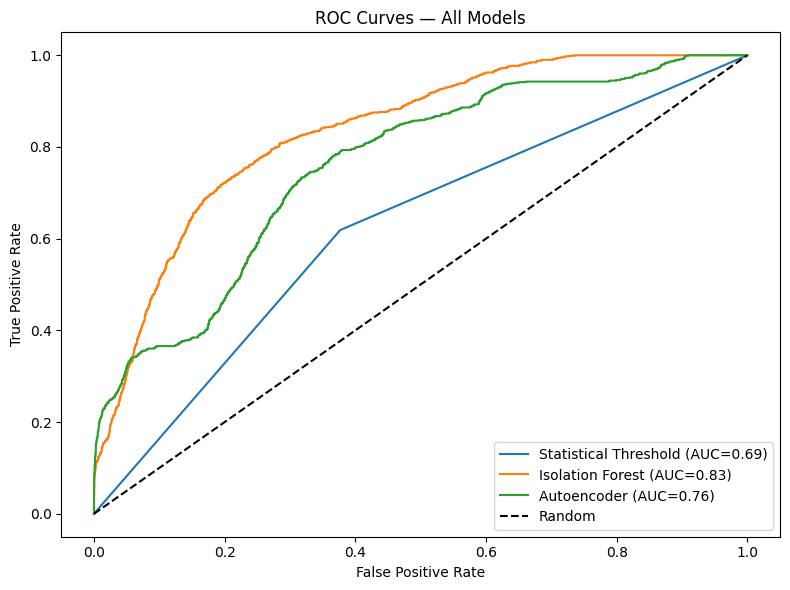

In [126]:
# ROC Curves of each model on one plot
fig, ax = plt.subplots(figsize=(8, 6))

fpr_st, tpr_st, _ = roc_curve(Y_test_sensor_readings_labels, threshold_predictions)
fpr_if, tpr_if, _ = roc_curve(Y_test_sensor_readings_labels, iso_scores)
fpr_ae, tpr_ae, _ = roc_curve(Y_test_sensor_readings_labels, ae_reconstruction_errors)

ax.plot(fpr_st, tpr_st, label="Statistical Threshold (AUC=0.69)")
ax.plot(fpr_if, tpr_if, label="Isolation Forest (AUC=0.83)")
ax.plot(fpr_ae, tpr_ae, label="Autoencoder (AUC=0.76)")
ax.plot([0, 1], [0, 1], "k--", label="Random")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend()
plt.tight_layout()
plt.savefig("results/sensor_readings/roc_curves.png", dpi=150)
plt.show()

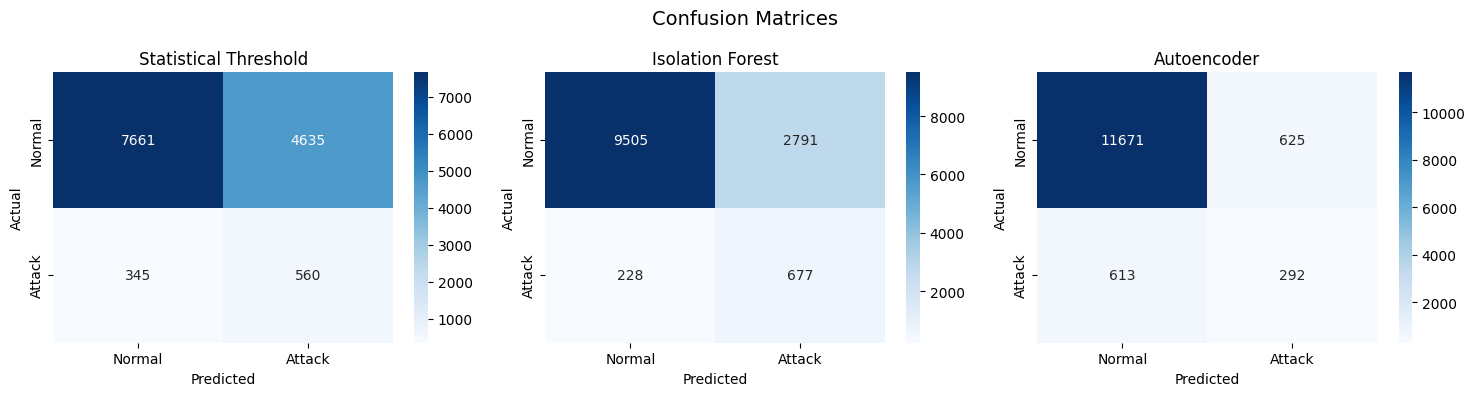

In [127]:
# Confusion Matrices for each model side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Statistical Threshold", threshold_predictions),
    ("Isolation Forest", iso_predictions),
    ("Autoencoder", ae_predictions),
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(Y_test_sensor_readings_labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.savefig("results/sensor_readings/confusion_matrices.png", dpi=150)
plt.show()

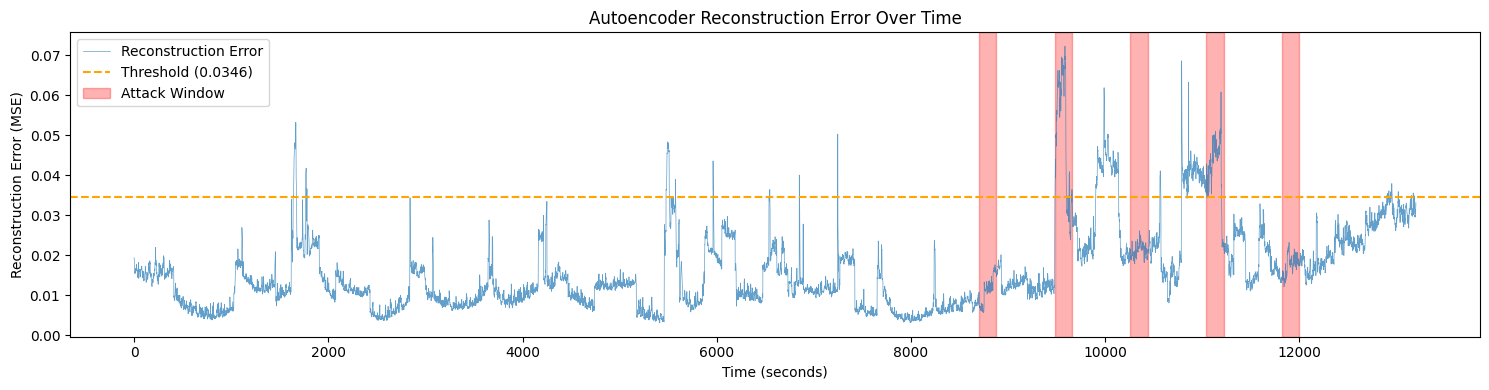

In [128]:
# Reconstruction Error Over Time for the Autoencoder Model
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(ae_reconstruction_errors, linewidth=0.5, label="Reconstruction Error", alpha=0.7)
ax.axhline(ae_threshold, color="orange", linestyle="--", label=f"Threshold ({ae_threshold:.4f})")

# Shade attack windows
attack_windows_idx = [
    (8700, 8880),   # 12:30 - 12:33
    (9480, 9660),   # 12:43 - 12:46
    (10260, 10440), # 12:56 - 12:59
    (11040, 11220), # 13:09 - 13:12
    (11820, 12000), # 13:22 - 13:25
]

for i, (start, end) in enumerate(attack_windows_idx):
    ax.axvspan(start, end, alpha=0.3, color="red",
               label="Attack Window" if i == 0 else "")

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Reconstruction Error (MSE)")
ax.set_title("Autoencoder Reconstruction Error Over Time")
ax.legend()
plt.tight_layout()
plt.savefig("results/sensor_readings/reconstruction_error.png", dpi=150)
plt.show()

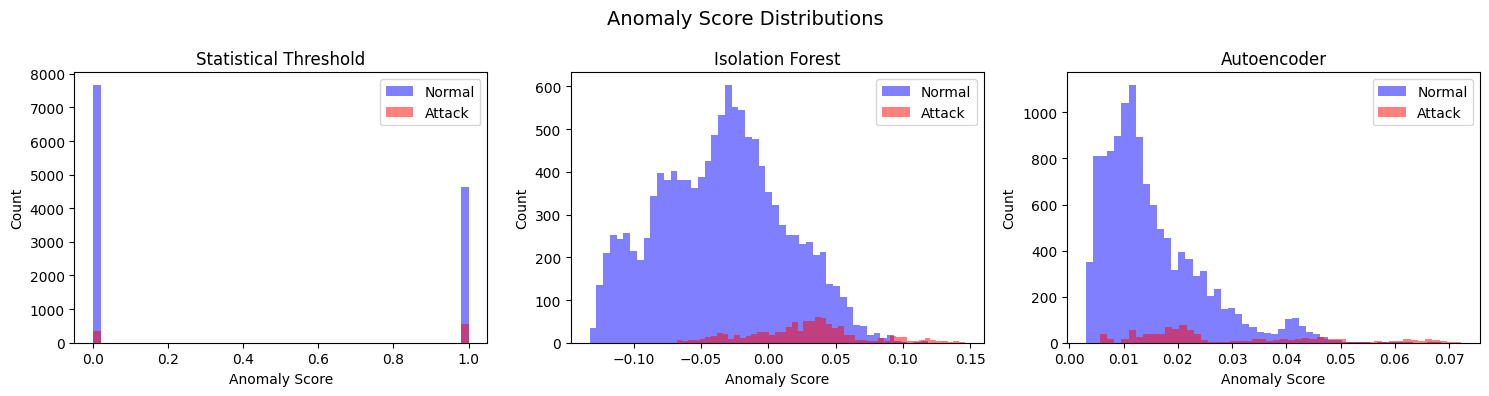

In [129]:
# Anomaly Score Distribution for Normal vs Attack Predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

score_data = [
    ("Statistical Threshold", threshold_predictions),
    ("Isolation Forest", iso_scores),
    ("Autoencoder", ae_reconstruction_errors),
]

for ax, (name, scores) in zip(axes, score_data):
    normal_scores = scores[Y_test_sensor_readings_labels == 0]
    attack_scores = scores[Y_test_sensor_readings_labels == 1]
    ax.hist(normal_scores, bins=50, alpha=0.5, label="Normal", color="blue")
    ax.hist(attack_scores, bins=50, alpha=0.5, label="Attack", color="red")
    ax.set_title(name)
    ax.set_xlabel("Anomaly Score")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Anomaly Score Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("results/sensor_readings/score_distributions.png", dpi=150)
plt.show()

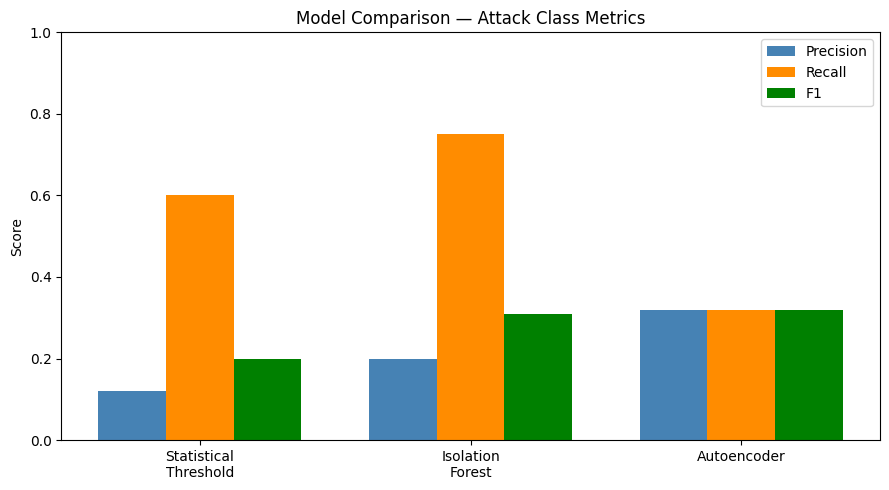

In [130]:

# F1, Precision, and Recall Bar Chart Model Comparisons
models_names = ["Statistical\nThreshold", "Isolation\nForest", "Autoencoder"]
precision_scores = [0.12, 0.20, 0.32]
recall_scores = [0.60, 0.75, 0.32]
f1_scores = [0.20, 0.31, 0.32]

x = np.arange(len(models_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, precision_scores, width, label="Precision", color="steelblue")
ax.bar(x, recall_scores, width, label="Recall", color="darkorange")
ax.bar(x + width, f1_scores, width, label="F1", color="green")

ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Model Comparison — Attack Class Metrics")
ax.legend()
plt.tight_layout()
plt.savefig("results/sensor_readings/model_comparison.png", dpi=150)
plt.show()

## Network Readings Preprocessing

In [7]:
# converting ms timestamps to more easily readable timezone adjusted timestamps for train/test sorting based on if attacks were present
network_readings_df["bidirectional_last_seen_timestamp"] = ((pd.to_datetime(network_readings_df["bidirectional_last_seen_ms"], unit="ms", utc=True)).dt.tz_convert("Asia/Shanghai")).dt.time
network_readings_df["bidirectional_first_seen_timestamp"] = ((pd.to_datetime(network_readings_df["bidirectional_first_seen_ms"], unit="ms", utc=True)).dt.tz_convert("Asia/Shanghai")).dt.time
network_readings_df["src2dst_first_seen_timestamp"] = ((pd.to_datetime(network_readings_df["src2dst_first_seen_ms"], unit="ms", utc=True)).dt.tz_convert("Asia/Shanghai")).dt.time
network_readings_df["src2dst_last_seen_timestamp"] = ((pd.to_datetime(network_readings_df["src2dst_last_seen_ms"], unit="ms", utc=True)).dt.tz_convert("Asia/Shanghai")).dt.time
network_readings_df["dst2src_first_seen_timestamp"] = ((pd.to_datetime(network_readings_df["dst2src_first_seen_ms"], unit="ms", utc=True)).dt.tz_convert("Asia/Shanghai")).dt.time
network_readings_df["dst2src_last_seen_timestamp"] = ((pd.to_datetime(network_readings_df["dst2src_last_seen_ms"], unit="ms", utc=True)).dt.tz_convert("Asia/Shanghai")).dt.time

# droppping ids, src and dst identifiers, already converted timestamps, and empty fields
drop_cols = ["id", "expiration_id", "src_ip", "src_mac", "src_oui", "dst_ip", "dst_mac", "dst_oui", "requested_server_name", "client_fingerprint", "server_fingerprint",
              "user_agent", "content_type", "bidirectional_last_seen_ms", "bidirectional_first_seen_ms", "src2dst_first_seen_ms", "src2dst_last_seen_ms", "dst2src_first_seen_ms", "dst2src_last_seen_ms"]
processed_network_df = network_readings_df.drop(columns=drop_cols, errors="ignore")

# encoding non-numeric features
processed_network_df = pd.get_dummies(processed_network_df, columns =["application_name", "application_category_name"], drop_first = True)

processed_network_df.head(5)

,src_port,dst_port,protocol,ip_version,vlan_id,tunnel_id,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_duration_ms,...,application_category_name_Collaborative,application_category_name_DataTransfer,application_category_name_IoT-Scada,application_category_name_Network,application_category_name_RPC,application_category_name_RemoteAccess,application_category_name_SoftwareUpdate,application_category_name_System,application_category_name_Unspecified,application_category_name_Web
0,39960,443,6,4,1,0,226,5,1085,28,...,False,False,False,False,False,False,False,False,False,True
1,443,40028,6,4,1,0,248,9,2189,248,...,False,False,False,False,False,False,False,False,False,True
2,443,39954,6,4,0,0,0,1,66,0,...,False,False,False,False,False,False,False,False,False,True
3,40024,443,6,4,0,0,236,4,264,236,...,False,False,False,False,False,False,False,False,False,True
4,39946,443,6,4,1,0,0,2,140,0,...,False,False,False,False,False,False,False,False,False,True


In [8]:
# creating the ranges of times where no attacks occured for training data
train_time_1_start = time(10, 5)
train_time_1_end = time(10, 19)
train_time_2_start = time(11, 21)
train_time_2_end = time(12, 29)

# the filter comparing the above ranges to the timestamp column
mask = (((processed_network_df["bidirectional_first_seen_timestamp"] > train_time_1_start) & (processed_network_df["bidirectional_last_seen_timestamp"] < train_time_1_end))
          | ((processed_network_df["bidirectional_first_seen_timestamp"] > train_time_2_start) & (processed_network_df["bidirectional_last_seen_timestamp"] < train_time_2_end)))

# seperating the train and test sets based on the filter
train_network_readings_df = processed_network_df[mask]
test_network_readings_df = processed_network_df[~mask]

attack_times = [(time(10, 30), time(10, 35)),
                (time(10, 45), time(10, 50)),
                 (time(11, 0), time(11, 5)),
                 (time(11, 15), time(11,20)),
                 (time(12, 30), time(12, 33)),
                 (time(12, 43), time(12, 46)),
                 (time(12, 56), time(12, 59)),
                 (time(13, 9), time(13, 12)),
                 (time(13, 22), time (13, 25))]

# labelling the data in the test set that is during an attack window, where data in the attack window is labeled 1 and data not in the attack window is labeled 0
test_network_readings_df["attack"] = 0
for start, end in attack_times:
    mask = (test_network_readings_df["bidirectional_first_seen_timestamp"] >= start) & (test_network_readings_df["bidirectional_last_seen_timestamp"] <= end)
    test_network_readings_df.loc[mask, "attack"] = 1

# seperating the label from the rest of the data for modeling
test_network_readings_labels = test_network_readings_df.pop("attack")


In [9]:
train_network_timestamp_columns = [col for col in train_network_readings_df.columns if "timestamp" in col]
test_network_timestamp_columns = [col for col in test_network_readings_df.columns if "timestamp" in col]

train_network_timestamps = train_network_readings_df[train_network_timestamp_columns].copy()
test_network_timestamps = test_network_readings_df[test_network_timestamp_columns].copy()

# dropping the timestamps from the train and test datasets
train_network_readings_df = train_network_readings_df.drop(columns = train_network_timestamp_columns)
test_network_readings_df = test_network_readings_df.drop(columns = test_network_timestamp_columns)


print(f"train set: {train_network_readings_df.shape}")
print(f"test set: {test_network_readings_df.shape}")
print(test_network_readings_labels.sum())
train_network_timestamps.columns
test_network_timestamps.columns

train set: (1651199, 59)
test set: (2977585, 59)
769483


Index(['bidirectional_last_seen_timestamp',
       'bidirectional_first_seen_timestamp', 'src2dst_first_seen_timestamp',
       'src2dst_last_seen_timestamp', 'dst2src_first_seen_timestamp',
       'dst2src_last_seen_timestamp'],
      dtype='str')

## Network Readings Evaluations

### Normalization and Modeling

In [10]:
# Initializing the MinMaxScaler
scaler = MinMaxScaler()

# Fitting the training data
X_train_network_readings_df = scaler.fit_transform(train_network_readings_df)

# Testing
X_test_network_readings_df = scaler.transform(test_network_readings_df)
Y_test_network_readings_labels = test_network_readings_labels.values

print("X_train shape:", X_train_network_readings_df.shape)
print("X_test shape:", X_test_network_readings_df.shape)



X_train shape: (1651199, 59)
X_test shape: (2977585, 59)


### Model 1 - Statistical Threshold

In [11]:
# Computing the mean and standard deviation from the training data
mean_train_network_readings =  X_train_network_readings_df.mean(axis=0)
std_train_network_readings =  X_train_network_readings_df.std(axis=0)

# Flag  anamoly if any feature exceeds the mean plus/minus 3 times the standard deviation
z_scores = np.abs((X_test_network_readings_df - mean_train_network_readings) / (std_train_network_readings + 1e-8))

# Max z-score per row
anomaly_scores = z_scores.max(axis=1)

# Replace NaN in anomaly scores with 0
anomaly_scores = np.nan_to_num(anomaly_scores, nan=0.0)

# Predictions
threshold_predictions = (anomaly_scores > 3).astype(int)

# Evaluate
print("=== Statistical Threshold ===")
print(classification_report(Y_test_network_readings_labels, threshold_predictions))
print("AUC:", roc_auc_score(Y_test_network_readings_labels, anomaly_scores))

=== Statistical Threshold ===
              precision    recall  f1-score   support

           0       0.79      0.89      0.84   2208102
           1       0.50      0.32      0.39    769483

    accuracy                           0.74   2977585
   macro avg       0.64      0.60      0.61   2977585
weighted avg       0.71      0.74      0.72   2977585

AUC: 0.5985703778278866


### Model 2 - Isolation Forest

In [12]:
# Training the IsolationForest Model
iso = IsolationForest(contamination=0.069, random_state=42, n_estimators=100)
iso.fit(X_train_network_readings_df)

# Predicting whether the IsolationForest model returns 1 (normal) and -1 (attack)
iso_predictions_raw = iso.predict(X_test_network_readings_df)

# Convert to 0 (normal) and 1 (attack)
iso_predictions = (iso_predictions_raw == -1).astype(int)

# Scores for AUC (lower score = more anomalous)
iso_scores = -iso.decision_function(X_test_network_readings_df)

# Evaluate
print("=== Isolation Forest ===")
print(classification_report(Y_test_network_readings_labels, iso_predictions))
print("AUC:", roc_auc_score(Y_test_network_readings_labels, iso_scores))

=== Isolation Forest ===
              precision    recall  f1-score   support

           0       0.78      0.90      0.84   2208102
           1       0.49      0.26      0.34    769483

    accuracy                           0.74   2977585
   macro avg       0.63      0.58      0.59   2977585
weighted avg       0.70      0.74      0.71   2977585

AUC: 0.6128348716399915


### Model 3 - Autoencoder

In [13]:
# Fixed random seeds for reproducibility purposes
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)

# Fixing any NaNs in the test data before converting it to a tensor
X_train_network_readings_df = pd.DataFrame(X_train_network_readings_df).ffill().bfill().values
X_test_network_readings_df = pd.DataFrame(X_test_network_readings_df).ffill().bfill().values

# Converting the training and testing data to tensors
X_train_network_readings_tensor = torch.FloatTensor(X_train_network_readings_df)
X_test_network_readings_tensor = torch.FloatTensor(X_test_network_readings_df)

# Verifing that there are no NaNs
print("X_train NaNs:", torch.isnan(X_train_network_readings_tensor).sum().item())
print("X_test NaNs:", torch.isnan(X_test_network_readings_tensor).sum().item())

train_network_readings_dataset = TensorDataset(X_train_network_readings_tensor, X_train_network_readings_tensor)
train_network_readings_loader = DataLoader(train_network_readings_dataset, batch_size=64, shuffle=False)

# Autoencoder Architecture
input_dim = X_train_network_readings_df.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Initializing torch to use Cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

autoencoder = Autoencoder(input_dim).to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Training the Autoencoder Model
epochs = 50
for epoch in range(epochs):
    autoencoder.train()
    total_loss = 0
    for batch_x, batch_y in train_network_readings_loader:
        batch_x = batch_x.to(device)
        reconstructed = autoencoder(batch_x)
        loss = criterion(reconstructed, batch_x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_network_readings_loader):.6f}")

# Threshold from training reconstruction error
autoencoder.eval()
with torch.no_grad():
    reconstructed_train = autoencoder(X_train_network_readings_tensor.to(device))
    train_reconstruction_errors = torch.mean(
        (X_train_network_readings_tensor.to(device) - reconstructed_train) ** 2, dim=1
    ).cpu().numpy()

ae_threshold = np.percentile(train_reconstruction_errors, 95)
print(f"\nAutoencoder threshold (95th percentile): {ae_threshold:.6f}")

# Reconstruction error on test set
with torch.no_grad():
    reconstructed_test = autoencoder(X_test_network_readings_tensor.to(device))
    ae_reconstruction_errors = torch.mean(
        (X_test_network_readings_tensor.to(device) - reconstructed_test) ** 2, dim=1
    ).cpu().numpy()

# Verifing any errors
print("Reconstruction errors NaNs:", np.isnan(ae_reconstruction_errors).sum())
print("Reconstruction errors shape:", ae_reconstruction_errors.shape)

# Predictions
ae_predictions = (ae_reconstruction_errors > ae_threshold).astype(int)

# Evaluate
print("=== Autoencoder ===")
print(classification_report(Y_test_network_readings_labels, ae_predictions))
print("AUC:", roc_auc_score(Y_test_network_readings_labels, ae_reconstruction_errors))

C:\Users\kyleb\AppData\Local\Temp\ipykernel_19288\3027725694.py:11: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  X_train_network_readings_tensor = torch.FloatTensor(X_train_network_readings_df)


X_train NaNs: 0
X_test NaNs: 0
Using device: cpu
Epoch 10/50 | Loss: 0.000010
Epoch 20/50 | Loss: 0.000008
Epoch 30/50 | Loss: 0.000014
Epoch 40/50 | Loss: 0.000007
Epoch 50/50 | Loss: 0.000008

Autoencoder threshold (95th percentile): 0.000102
Reconstruction errors NaNs: 0
Reconstruction errors shape: (2977585,)
=== Autoencoder ===
              precision    recall  f1-score   support

           0       0.77      0.93      0.84   2208102
           1       0.48      0.20      0.29    769483

    accuracy                           0.74   2977585
   macro avg       0.63      0.56      0.56   2977585
weighted avg       0.70      0.74      0.70   2977585

AUC: 0.6136271911983292


## Network Reading Visualizations

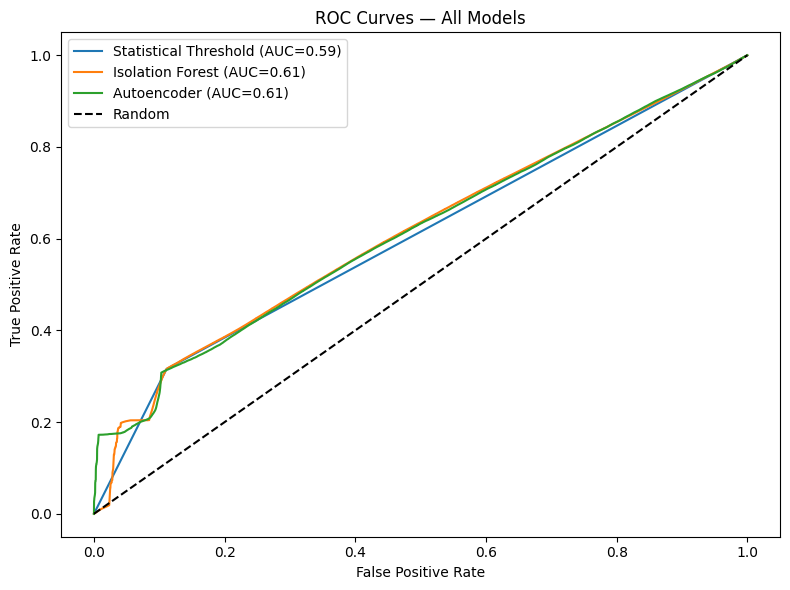

In [14]:
# ROC Curves of each model on one plot
fig, ax = plt.subplots(figsize=(8, 6))

fpr_st, tpr_st, _ = roc_curve(Y_test_network_readings_labels, threshold_predictions)
fpr_if, tpr_if, _ = roc_curve(Y_test_network_readings_labels, iso_scores)
fpr_ae, tpr_ae, _ = roc_curve(Y_test_network_readings_labels, ae_reconstruction_errors)

ax.plot(fpr_st, tpr_st, label="Statistical Threshold (AUC=0.59)")
ax.plot(fpr_if, tpr_if, label="Isolation Forest (AUC=0.61)")
ax.plot(fpr_ae, tpr_ae, label="Autoencoder (AUC=0.61)")
ax.plot([0, 1], [0, 1], "k--", label="Random")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend()
plt.tight_layout()
plt.savefig("results/network_readings/roc_curves.png", dpi=150)
plt.show()

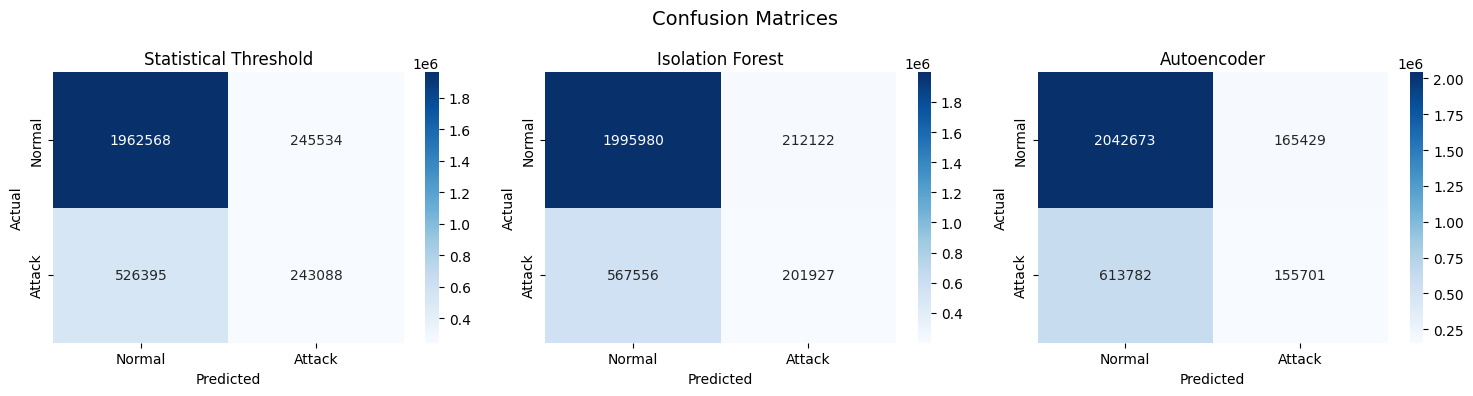

In [15]:
# Confusion Matrices for each model side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Statistical Threshold", threshold_predictions),
    ("Isolation Forest", iso_predictions),
    ("Autoencoder", ae_predictions),
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(Y_test_network_readings_labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.savefig("results/network_readings/confusion_matrices.png", dpi=150)
plt.show()

In [27]:
print(len(test_network_timestamps))
print(len(ae_reconstruction_errors))

2977585
2977585


C:\Users\kyleb\AppData\Local\Temp\ipykernel_19288\446494704.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


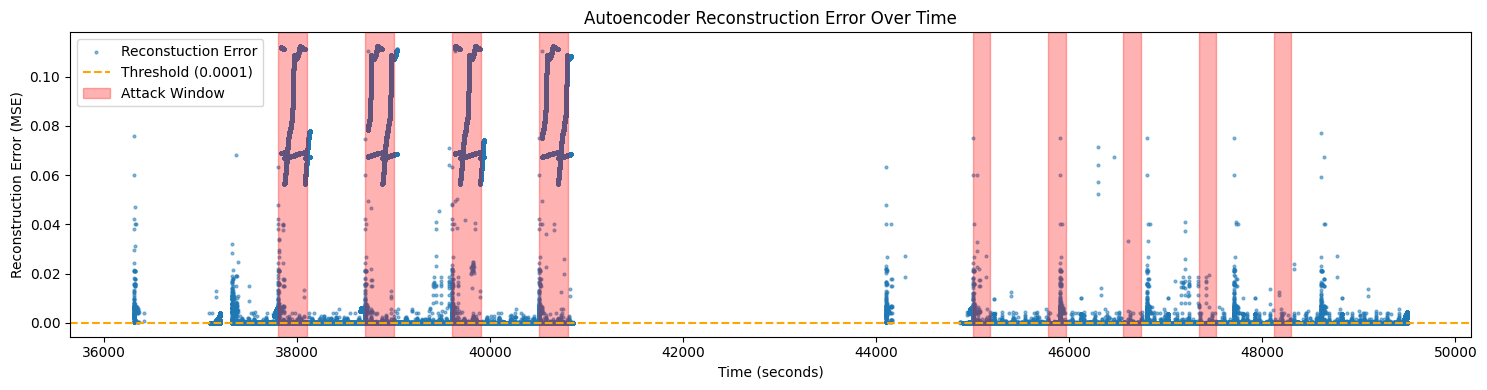

In [28]:
# Reconstruction Error Over Time for the Autoencoder Model
fig, ax = plt.subplots(figsize=(15, 4))
timestamp_in_seconds = test_network_timestamps["bidirectional_first_seen_timestamp"].apply(
    lambda t: t.hour*3600 + t.minute*60 + t.second + t.microsecond/1e6
)

ax.scatter(timestamp_in_seconds, ae_reconstruction_errors, s=4, alpha=0.5, label="Reconstuction Error")
#ax.plot(timestamp_in_seconds, ae_reconstruction_errors, linewidth=0.5, label="Reconstruction Error", alpha=0.7)
ax.axhline(ae_threshold, color="orange", linestyle="--", label=f"Threshold ({ae_threshold:.4f})")

# Shade attack windows
attack_windows_idx = [
    (37800, 38100), # 10:30 - 10:35
    (38700, 39000), # 10:45 - 10:50
    (39600, 39900), # 11:00 - 11:05
    (40500, 40800), # 11:15 - 11:20
    (45000, 45180), # 12:30 - 12:33
    (45780, 45960), # 12:43 - 12:46
    (46560, 46740), # 12:56 - 12:59
    (47340, 47520), # 13:09 - 13:12
    (48120, 48300), # 13:22 - 13:25
]

for i, (start, end) in enumerate(attack_windows_idx):
    ax.axvspan(start, end, alpha=0.3, color="red",
    label="Attack Window" if i == 0 else "")

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Reconstruction Error (MSE)")
ax.set_title("Autoencoder Reconstruction Error Over Time")
ax.legend()
plt.tight_layout()
plt.savefig("results/network_readings/reconstruction_error.png", dpi=150)
plt.show()

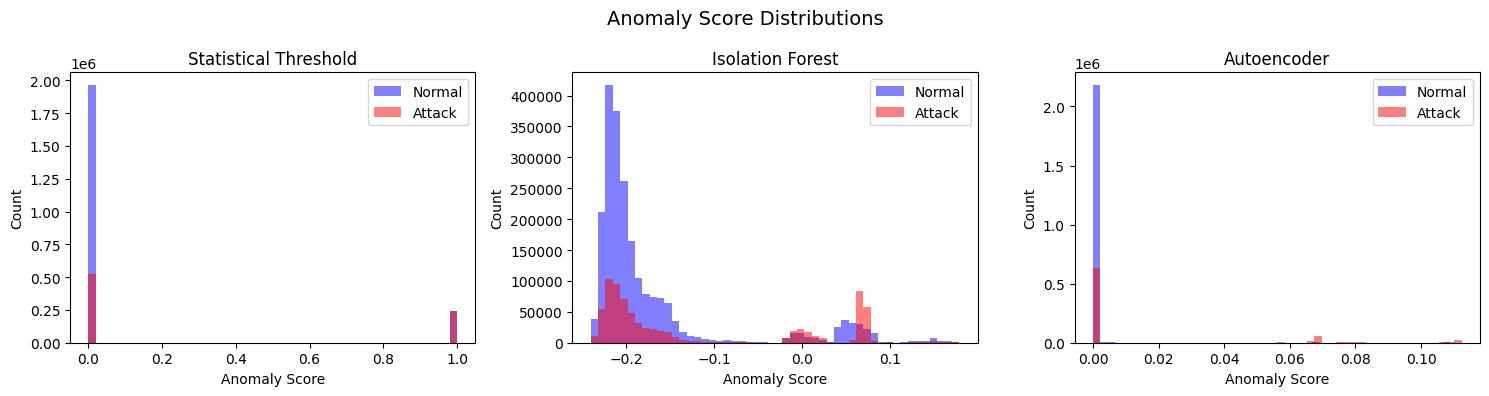

In [20]:
# Anomaly Score Distribution for Normal vs Attack Predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

score_data = [
    ("Statistical Threshold", threshold_predictions),
    ("Isolation Forest", iso_scores),
    ("Autoencoder", ae_reconstruction_errors),
]

for ax, (name, scores) in zip(axes, score_data):
    normal_scores = scores[Y_test_network_readings_labels == 0]
    attack_scores = scores[Y_test_network_readings_labels == 1]
    ax.hist(normal_scores, bins=50, alpha=0.5, label="Normal", color="blue")
    ax.hist(attack_scores, bins=50, alpha=0.5, label="Attack", color="red")
    ax.set_title(name)
    ax.set_xlabel("Anomaly Score")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Anomaly Score Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("results/network_readings/score_distributions.png", dpi=150)
plt.show()

In [ ]:
# # F1, Precision, and Recall Bar Chart Model Comparisons
# models_names = ["Statistical\nThreshold", "Isolation\nForest", "Autoencoder"]
# precision_scores = [0.12, 0.20, 0.32]
# recall_scores = [0.60, 0.75, 0.32]
# f1_scores = [0.20, 0.31, 0.32]

# x = np.arange(len(models_names))
# width = 0.25

# fig, ax = plt.subplots(figsize=(9, 5))
# ax.bar(x - width, precision_scores, width, label="Precision", color="steelblue")
# ax.bar(x, recall_scores, width, label="Recall", color="darkorange")
# ax.bar(x + width, f1_scores, width, label="F1", color="green")

# ax.set_xticks(x)
# ax.set_xticklabels(models_names)
# ax.set_ylabel("Score")
# ax.set_ylim(0, 1)
# ax.set_title("Model Comparison — Attack Class Metrics")
# ax.legend()
# plt.tight_layout()
# plt.savefig("results/network_readings/model_comparison.png", dpi=150)
# plt.show()